In [1]:
import os
import yaml
import copy

import numpy as np
import pandas as pd
import xarray as xr

In [17]:
import cmaps
# graph tools
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as colors
import matplotlib.colorbar as cbar
import matplotlib.ticker as ticker
from matplotlib.ticker import ScalarFormatter
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.AX_grid1.inset_locator import inset_AX

import cartopy.crs as ccrs
import cartopy.mpl.geoAX
import cartopy.feature as cfeature

%matplotlib inline

## Locations

## Geo info

In [3]:
ds_static = xr.open_zarr('/glade/derecho/scratch/ksha/EPRI_data/static/static.zarr')
lon = ds_static['lon'].values
lat = ds_static['lat'].values

In [16]:
gridx, gridy = np.meshgrid(lon, lat)

## Map creation

In [18]:
scale_param = '50m'

PROVINCE = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_1_states_provinces_lines',
    scale=scale_param,
    facecolor='none')

def map_gridline_opt(ax):
    '''
    Customize cartopy map gridlines
    '''
    # lat/lon gridlines and labeling

    GL = ax.gridlines(crs=ccrs.PlateCarree(), 
                      draw_labels=False, x_inline=False, y_inline=False, 
                      color='k', linewidth=0.1, linestyle=':', zorder=5)
    GL.top_labels = None; GL.bottom_labels = None
    GL.right_labels = None; GL.left_labels = None
    GL.xlabel_style = {'size': 14}; GL.ylabel_style = {'size': 14}
    GL.rotate_labels = False
    ax.add_feature(cfeature.BORDERS.with_scale(scale_param), linestyle='-', linewidth=2.5, zorder=7)
    ax.add_feature(PROVINCE, edgecolor='k', linestyle='-', linewidth=2.5, zorder=7)
    ax.add_feature(cfeature.COASTLINE.with_scale(scale_param ), edgecolor='k', linewidth=2.5, zorder=5)
    ax.spines['geo'].set_linewidth(2.5)
    return ax

In [ ]:
29.64, 43.04

In [22]:
43.04 - 33.125

9.915

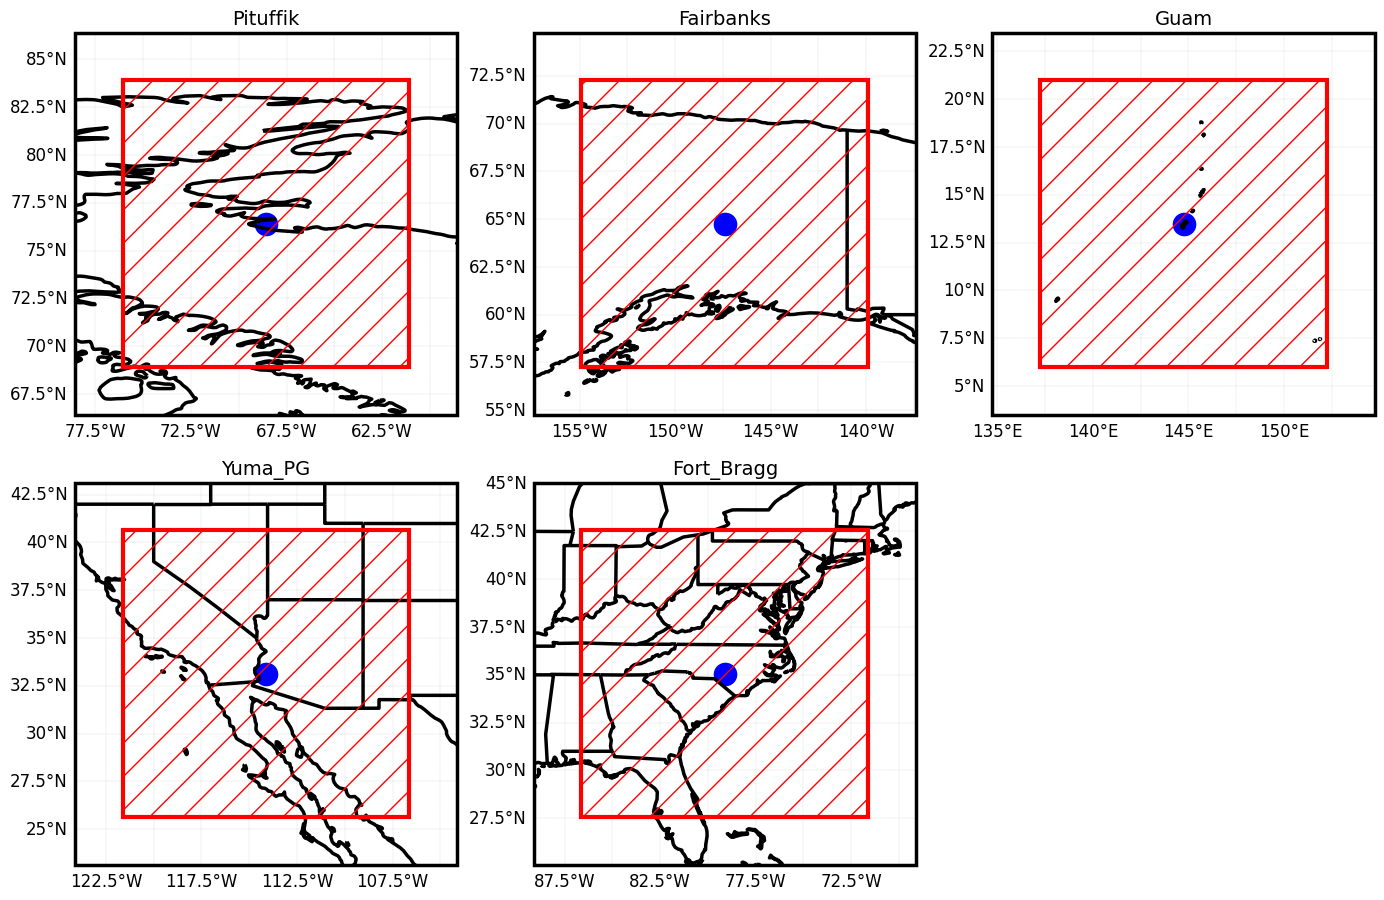

In [38]:
dict_loc = {
    'Pituffik': (76.4, -68.575),
    'Fairbanks': (64.75, -147.4),
    'Guam': (13.475, 144.75),
    'Yuma_PG': (33.125, -114.125),
    'Fort_Bragg': (35.05, -79.115),
}

keys = list(dict_loc.keys())

# ---- layout: 2x3 ----
fig = plt.figure(figsize=(13, 9))
proj_ = ccrs.PlateCarree()

gs = gridspec.GridSpec(2, 3)
AX = []
AX.append(plt.subplot(gs[0, 0], projection=proj_))
AX.append(plt.subplot(gs[0, 1], projection=proj_))
AX.append(plt.subplot(gs[0, 2], projection=proj_))
AX.append(plt.subplot(gs[1, 0], projection=proj_))
AX.append(plt.subplot(gs[1, 1], projection=proj_))
# AX.append(plt.subplot(gs[1, 2], projection=proj_))
plt.subplots_adjust(0, 0, 1, 1, hspace=0.0, wspace=0.2)

# ---- plot each station into one panel ----
stn_pad = 7.5      # deg
map_edge_pad = 2.5 # deg

for i, key in enumerate(keys):
    ax = AX[i]
    stn_lat, stn_lon = dict_loc[key]

    domain = [
        stn_lon - stn_pad,
        stn_lon + stn_pad,
        stn_lat - stn_pad,
        stn_lat + stn_pad
    ]

    map_extent = [
        domain[0] - map_edge_pad,
        domain[1] + map_edge_pad,
        domain[2] - map_edge_pad,
        domain[3] + map_edge_pad
    ]

    ax.set_extent(map_extent, crs=proj_)
    ax = map_gridline_opt(ax)

    GL = ax.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=True, x_inline=False, y_inline=False,
        color='k', linewidth=0, linestyle=':', zorder=5
    )
    GL.top_labels = None
    GL.right_labels = None
    GL.xlabel_style = {'size': 12}
    GL.ylabel_style = {'size': 12}

    lon_min, lon_max, lat_min, lat_max = domain
    ax.add_patch(
        plt.Rectangle(
            (lon_min, lat_min),
            lon_max - lon_min,
            lat_max - lat_min,
            transform=ccrs.PlateCarree(),
            edgecolor='r',
            facecolor='none',
            linestyle='-',
            linewidth=3,
            hatch='/',
            zorder=10
        )
    )

    ax.plot(stn_lon, stn_lat, 'bo', ms=16, transform=ccrs.PlateCarree())
    ax.set_title(key, fontsize=14)